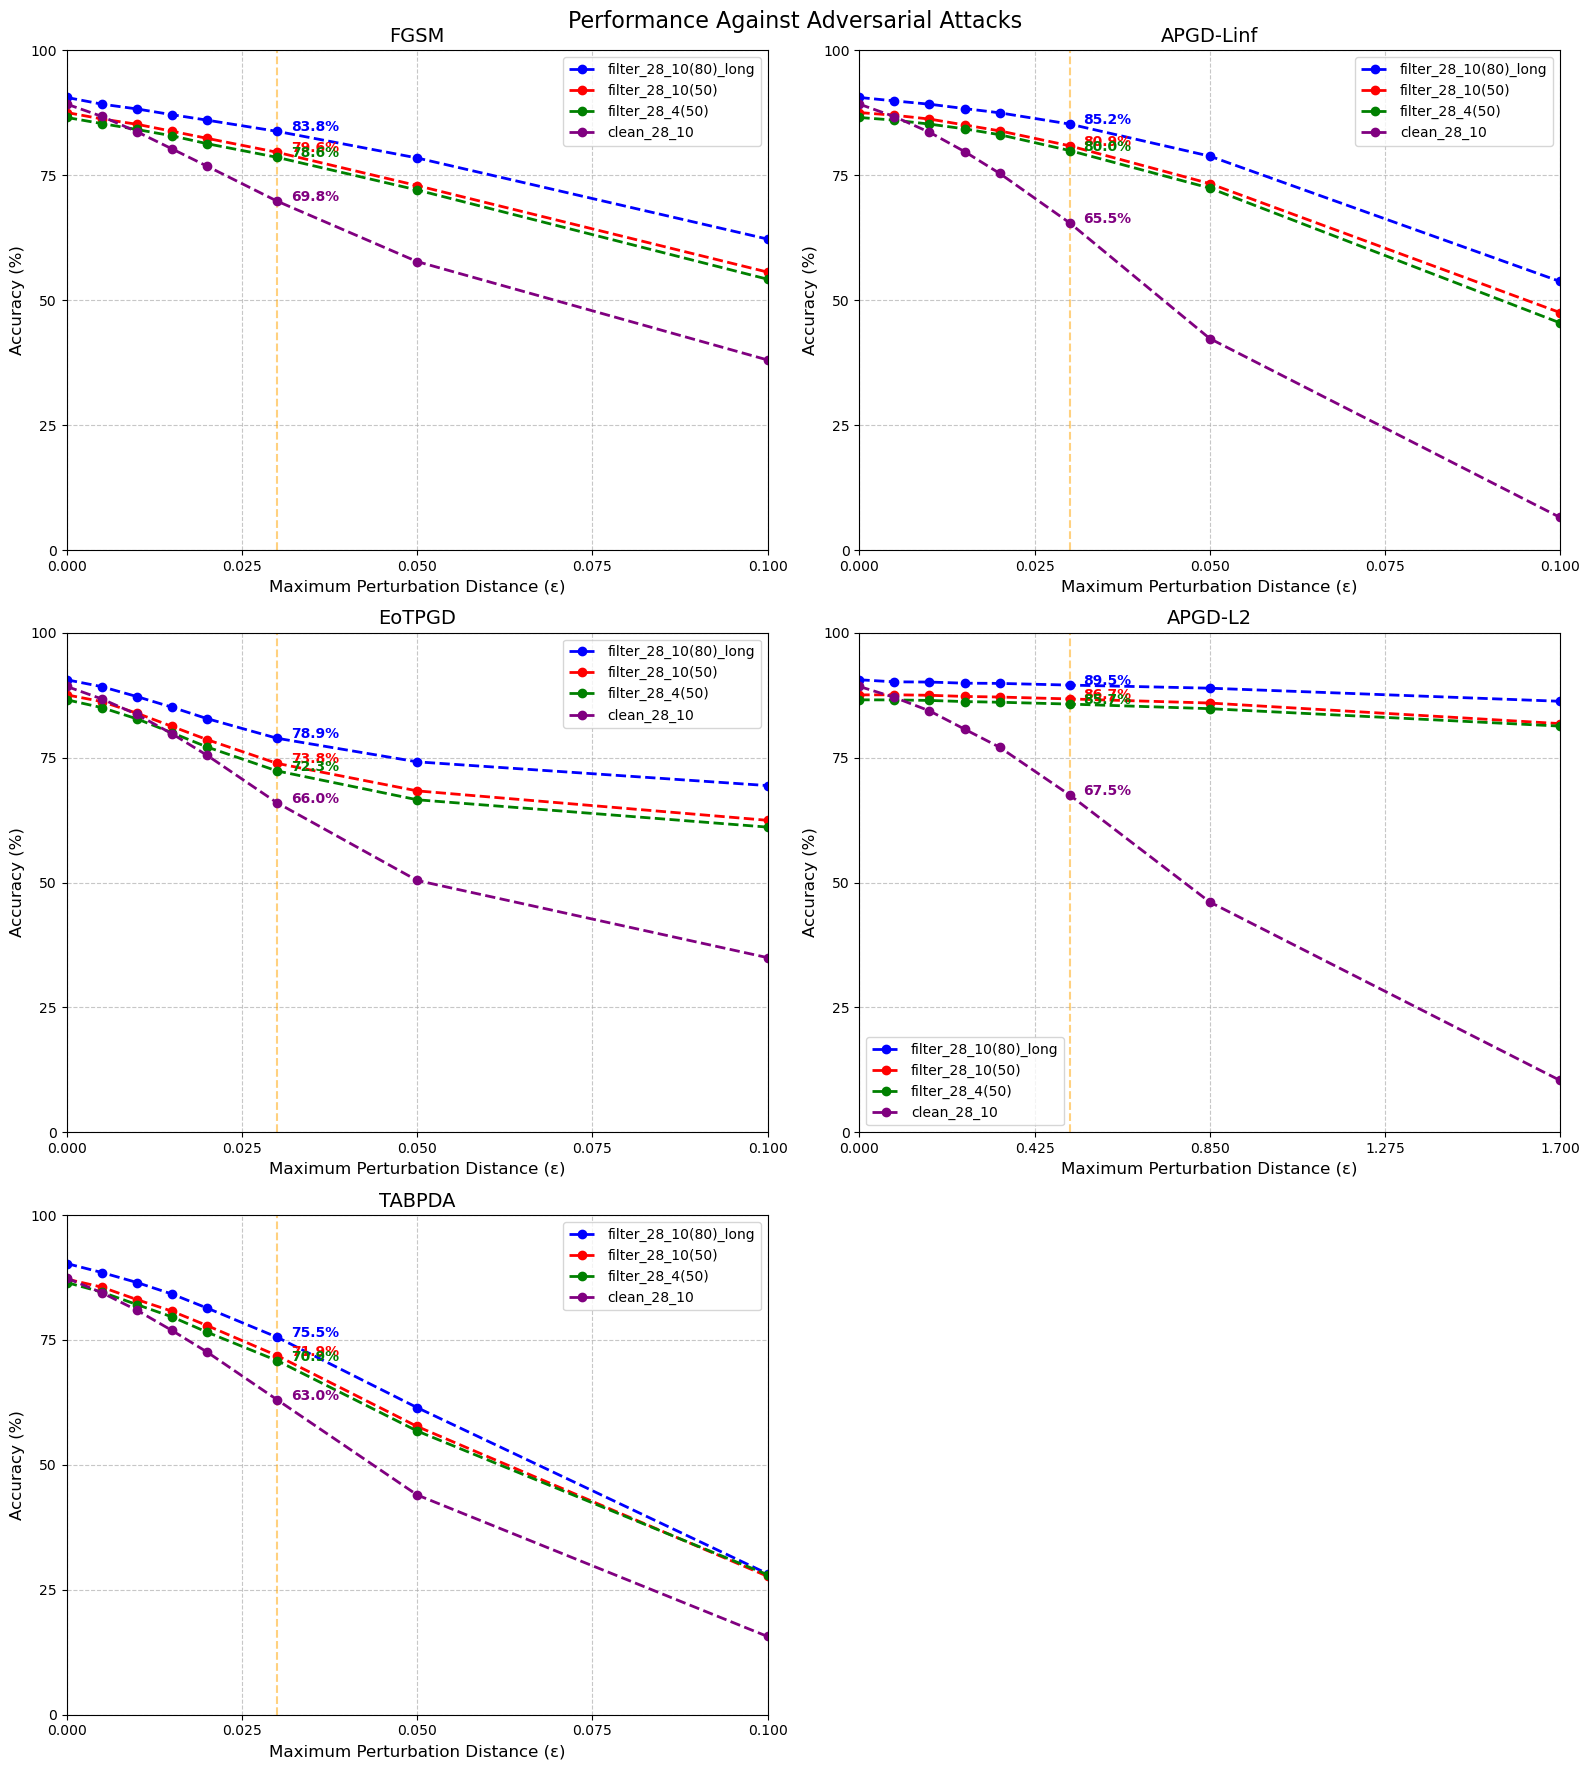

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Epsilon values
epsilon_values = np.array([0.00, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05, 0.1])
# Attack types matching the rows in the data (now with 5 attacks)
attack_types = ["FGSM", "APGD-Linf", "EoTPGD", "APGD-L2", "TABPDA"]

def read_accuracy_from_excel(file_paths):
    """
    Read accuracy data from multiple Excel files.
    
    Parameters:
    file_paths (list): List of file paths to Excel files
    
    Returns:
    list: List of accuracy data from each file
    """
    all_accuracies = []
    
    for file_path in file_paths:
        try:
            # Read the Excel file
            df = pd.read_excel(file_path, index_col=0)
            
            # Convert to numpy array and append to list
            accuracies = df.values
            all_accuracies.append(accuracies)
            
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    return all_accuracies

def read_eotbpda_accuracy(file_paths):
    """
    Read EoTBPDA accuracy data from separate Excel files.
    
    Parameters:
    file_paths (list): List of paths to Excel files containing EoTBPDA data
    
    Returns:
    list: List of EoTBPDA accuracy data for each model configuration
    """
    eotbpda_accuracies = []
    
    for file_path in file_paths:
        try:
            # Read the Excel file
            df = pd.read_excel(file_path, index_col=0)
            
            # Convert to numpy array and get the first row
            # Each file corresponds to one model configuration
            accuracies = df.values[0, :]  # Extract first row (assuming EoTBPDA is in first row)
            eotbpda_accuracies.append(accuracies)
        
        except Exception as e:
            print(f"Error reading EoTBPDA file {file_path}: {e}")
            # In case of error, append zeros
            eotbpda_accuracies.append(np.zeros_like(epsilon_values))
    
    return eotbpda_accuracies

def find_nearest_index(array, value):
    """
    Find the index of the nearest value in the array.
    
    Parameters:
    array (numpy.ndarray): Input array
    value (float): Value to find
    
    Returns:
    int: Index of the nearest value
    """
    return np.argmin(np.abs(array - value))

def plot_attack_performance(epsilon_values, all_accuracies, attack_types, label, eotbpda_accuracies=None):
    """
    Create performance plots for different adversarial attacks from multiple files.
    """
    # Create a figure with a 3x2 grid for 5 attack types
    fig, axs = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('Performance Against Adversarial Attacks', fontsize=16)
    
    # Flatten the axes for easier iteration
    axs_flat = axs.flatten()
    
    # Color cycle for multiple files
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']
    x_ticks = np.array([0.000, 0.025, 0.050, 0.075, 0.100])
    x_max = 0.1
    vertical_line_x = 0.03
    
    # Create plots for each attack type
    for i, attack_type in enumerate(attack_types):
        if i >= len(axs_flat):
            break  # In case we have more attack types than subplots
            
        # Get current subplot
        ax = axs_flat[i]

        # Adjust x-values for the APGD-L2
        current_epsilon_values = epsilon_values.copy()
        current_x_ticks = x_ticks.copy()
        current_x_max = x_max
        current_vertical_line_x = vertical_line_x

        if i == 3:  # APGD-L2
            current_epsilon_values = current_epsilon_values * 17
            current_x_ticks = current_x_ticks * 17
            current_x_max = current_x_max * 17
            current_vertical_line_x = vertical_line_x * 17

        # Find the index of the nearest epsilon value
        line_index = find_nearest_index(current_epsilon_values, current_vertical_line_x)

        # Draw vertical line
        ax.axvline(x=current_vertical_line_x, color='orange', linestyle='--', linewidth=1.5, alpha=0.5)
        
        # For regular attack types (0-3)
        if i < 4:
            # Plot data for each file and annotate accuracies
            for j, accuracies in enumerate(all_accuracies):
                # Get data for this specific attack type (row i from the data)
                attack_data = accuracies[i, :]
                
                # Plot with a different color for each file
                ax.plot(current_epsilon_values, attack_data * 100, 
                        color=colors[j % len(colors)], 
                        marker='o', 
                        linestyle='--', 
                        linewidth=2,
                        label=label[j])
                
                # Annotate accuracy at the vertical line
                accuracy_at_point = attack_data[line_index] * 100
                ax.annotate(f'{accuracy_at_point:.1f}%', 
                            xy=(current_vertical_line_x, accuracy_at_point), 
                            xytext=(10, 0), 
                            textcoords='offset points',
                            color=colors[j % len(colors)],
                            fontweight='bold')
        # For EoTBPDA (i=4)
        else:
            if eotbpda_accuracies:
                # Plot EoTBPDA data for each model configuration
                for j, attack_data in enumerate(eotbpda_accuracies):
                    # Plot with a different color for each file
                    ax.plot(current_epsilon_values, attack_data * 100, 
                            color=colors[j % len(colors)], 
                            marker='o', 
                            linestyle='--', 
                            linewidth=2,
                            label=label[j])
                    
                    # Annotate accuracy at the vertical line
                    accuracy_at_point = attack_data[line_index] * 100
                    ax.annotate(f'{accuracy_at_point:.1f}%', 
                                xy=(current_vertical_line_x, accuracy_at_point), 
                                xytext=(10, 0), 
                                textcoords='offset points',
                                color=colors[j % len(colors)],
                                fontweight='bold')
        
        # Set titles and labels
        ax.set_title(f'{attack_type}', fontsize=14)
        ax.set_xlabel('Maximum Perturbation Distance (ε)', fontsize=12)
        ax.set_ylabel('Accuracy (%)', fontsize=12)
        
        # Set y-axis limits and ticks
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        
        # Set x-axis limits and ticks
        ax.set_xlim(0, current_x_max)
        ax.set_xticks(current_x_ticks)
        
        # Add grid
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Add legend
        ax.legend()
    
    # Hide the unused subplot (in a 3x2 grid, we have 6 subplots but only 5 attack types)
    if len(attack_types) < len(axs_flat):
        axs_flat[-1].axis('off')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('multi_file_adversarial_attacks_performance.png', dpi=300)
    
    # Show the figure
    plt.show()

def main():
    # List of file paths for the original 4 attacks
    file_paths = [
        './mult_adv/long_bil/acc.xlsx',
        './mult_adv/bil_28_10(50)/acc.xlsx',
        './mult_adv/bil_28_4(50)/acc.xlsx',
        './mult_adv/clean_28_10/acc.xlsx'
    ]
    
    # Path for the EoTBPDA data - one file per model configuration
    eotbpda_file_paths = [
        './mult_adv/EoTBPDA/bil_28_10l(80)/acc.xlsx',
        './mult_adv/EoTBPDA/bil_28_10(50)/acc.xlsx',
        './mult_adv/EoTBPDA/bil_28_4(50)/acc.xlsx',
        './mult_adv/EoTBPDA/clean_28_4/acc.xlsx'
    ]
    
    label = ['filter_28_10(80)_long', 'filter_28_10(50)', 'filter_28_4(50)', 'clean_28_10']

    # Read accuracy data from multiple files
    all_accuracies = read_accuracy_from_excel(file_paths)
    
    # Read EoTBPDA data from its files
    eotbpda_accuracies = read_eotbpda_accuracy(eotbpda_file_paths)
    
    if all_accuracies and eotbpda_accuracies:
        # Plot performance for each attack type, including EoTBPDA
        plot_attack_performance(epsilon_values, all_accuracies, attack_types, label, eotbpda_accuracies)
    else:
        print("Could not read accuracy data. Please check the file paths and formats.")

# Run the main function
if __name__ == "__main__":
    main()

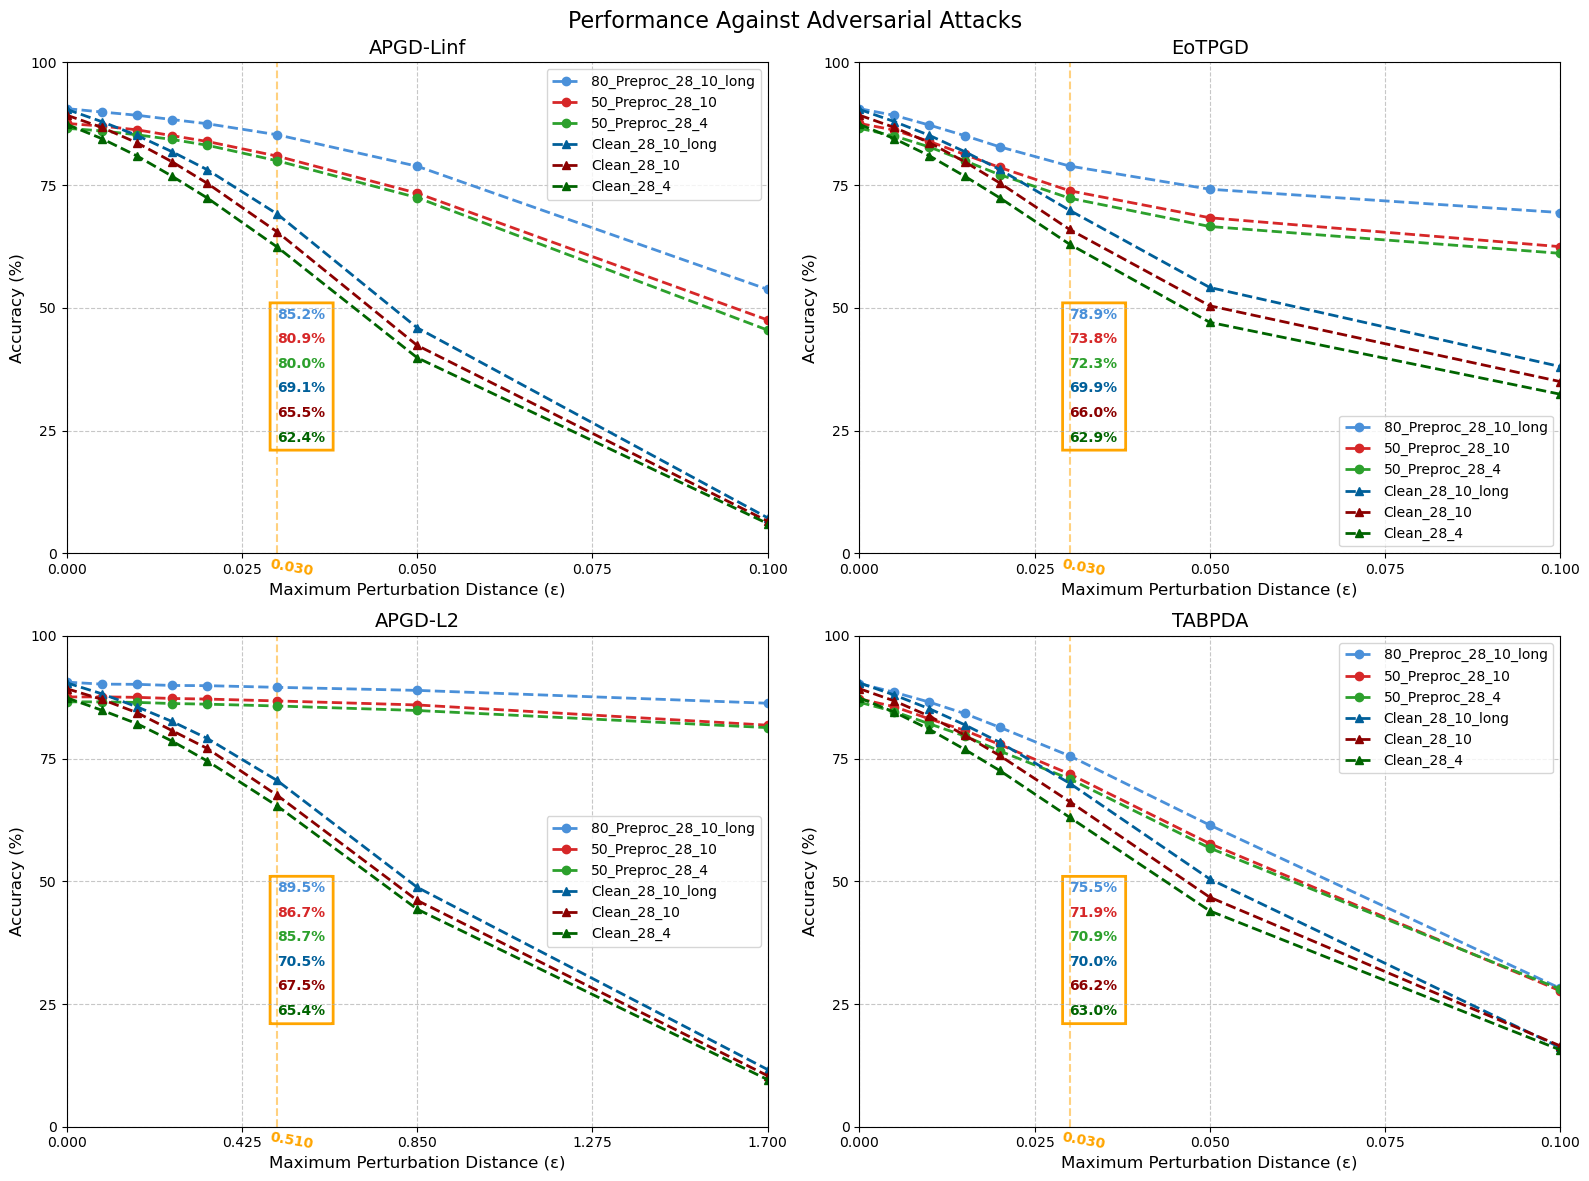

In [2]:
from matplotlib.patches import FancyBboxPatch

def plot_attack_performance(epsilon_values, all_accuracies, attack_types, label, eotbpda_accuracies=None):
    """
    Create performance plots for different adversarial attacks from multiple files.
    Added accuracy values on the right side of the vertical line, below 45 on y-axis.
    """
    # Create a figure with a 3x2 grid for 5 attack types
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Performance Against Adversarial Attacks', fontsize=16)
    
    # Flatten the axes for easier iteration
    axs_flat = axs.flatten()
    
    # Color cycle for multiple files
    colors = [
    '#4a90d9',  # blue (standard)
    '#d62728',  # red (standard)
    '#2ca02c',  # green (standard)

    '#005f99',  # blue (darker)
    '#8b0000',  # red (darker, crimson)
    '#006400',  # green (darker, forest)

    '#ff7f0e',  # orange
    '#9467bd',  # purple
    '#17becf',  # cyan/teal
    '#8c564b',  # brown
]
    x_ticks = np.array([0.000, 0.025, 0.050, 0.075, 0.100])
    x_max = 0.1
    vertical_line_x = 0.03
    
    # Create plots for each attack type
    for i, attack_type in enumerate(attack_types):
        if i == 0:
            continue
            
        # Get current subplot
        ax = axs_flat[i-1]

        # Adjust x-values for the APGD-L2
        current_epsilon_values = epsilon_values.copy()
        current_x_ticks = x_ticks.copy()
        current_x_max = x_max
        current_vertical_line_x = vertical_line_x

        if i == 3:  # APGD-L2
            current_epsilon_values = current_epsilon_values * 17
            current_x_ticks = current_x_ticks * 17
            current_x_max = current_x_max * 17
            current_vertical_line_x = vertical_line_x * 17

        # Find the index of the nearest epsilon value
        line_index = find_nearest_index(current_epsilon_values, current_vertical_line_x)

        # Draw vertical line
        ax.axvline(x=current_vertical_line_x, color='orange', linestyle='--', linewidth=1.5, alpha=0.5)

        # Add x-axis label for the vertical line
        if i == 3:
            ax.text(current_vertical_line_x + 3.5e-2, -8e-3, f'{current_vertical_line_x:.3f}',
                color='orange', fontsize=10,
                ha='center', va='top', fontweight='bold',
                transform=ax.get_xaxis_transform(),
                rotation= -10)
        
        else:
            ax.text(current_vertical_line_x + 2e-3, -8e-3, f'{current_vertical_line_x:.3f}',
                color='orange', fontsize=10,
                ha='center', va='top', fontweight='bold',
                transform=ax.get_xaxis_transform(),
                rotation= -10)
        
        # Collect accuracies for annotations
        annotations = []
        
        # For regular attack types (0-3)
        if i < 4:
            # Plot data for each file and collect accuracy values
            for j, accuracies in enumerate(all_accuracies):
                # Get data for this specific attack type (row i from the data)
                attack_data = accuracies[i, :]
                if j < 3:
                    marker = 'o'
                else:
                    marker = '^'
                # Plot with a different color for each file
                line = ax.plot(current_epsilon_values, attack_data * 100, 
                        color=colors[j % len(colors)], 
                        marker=marker, 
                        linestyle='--', 
                        linewidth=2,
                        label=label[j])
                
                # Collect accuracy at the vertical line for annotation
                accuracy_at_point = attack_data[line_index] * 100
                annotations.append((j, accuracy_at_point, colors[j % len(colors)]))
                
        # For EoTBPDA (i=4)
        else:
            if eotbpda_accuracies:
                # Plot EoTBPDA data for each model configuration
                for j, attack_data in enumerate(eotbpda_accuracies):

                    if j < 3:
                        marker = 'o'
                    else:
                        marker = '^'
                    # Plot with a different color for each file
                    line = ax.plot(current_epsilon_values, attack_data * 100, 
                            color=colors[j % len(colors)], 
                            marker=marker, 
                            linestyle='--', 
                            linewidth=2,
                            label=label[j])
                    
                    # Collect accuracy at the vertical line for annotation
                    accuracy_at_point = attack_data[line_index] * 100
                    annotations.append((j, accuracy_at_point, colors[j % len(colors)]))
        
        # Sort annotations by accuracy value (descending)
        annotations.sort(key=lambda x: x[1], reverse=True)
        
        # Base position for the box and annotations
        x_position = current_vertical_line_x 
        y_start = 50
        line_spacing = 5

        # Estimate box height and width
        box_height = line_spacing * len(annotations)
        box_width = 7e-2*current_x_max # adjust as needed for longer accuracy strings
        pad = 1e-2*current_x_max

        # Draw a box (orange outline only)
        box = FancyBboxPatch(
            (x_position, y_start - box_height + 1),  # (x, y) bottom left
            box_width, box_height,
            boxstyle="round,pad=" + str(pad),
            edgecolor="orange",
            facecolor="none",
            linewidth=2,
            transform=ax.transData,
            zorder=1
        )
        ax.add_patch(box)

        # Add each colored accuracy text line inside the box
        for idx, (j, accuracy, color) in enumerate(annotations):
            y_position = y_start - (idx * line_spacing)
            ax.text(x_position, y_position,
                    f"{accuracy:.1f}%",
                    color=color,
                    fontweight='bold',
                    verticalalignment='top',
                    horizontalalignment='left',
                    zorder=2)
        
        # Set titles and labels
        ax.set_title(f'{attack_type}', fontsize=14)
        ax.set_xlabel('Maximum Perturbation Distance (ε)', fontsize=12)
        ax.set_ylabel('Accuracy (%)', fontsize=12)
        
        # Set y-axis limits and ticks
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        
        # Set x-axis limits and ticks
        ax.set_xlim(0, current_x_max)
        ax.set_xticks(current_x_ticks)
        
        # Add grid
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Add legend
        ax.legend()
    
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig("SotA_mult_adv.svg")
    # Show the figure
    plt.show()

def main():
    # List of file paths for the original 4 attacks
    file_paths = [
        './mult_adv/long_bil/acc.xlsx',
        './mult_adv/bil_28_10(50)/acc.xlsx',
        './mult_adv/bil_28_4(50)/acc.xlsx',
        './mult_adv/clean_28_10l/acc.xlsx' ,
        './mult_adv/clean_28_10/acc.xlsx',
        './mult_adv/clean_28_4/acc.xlsx'
    ]

    # Path for the EoTBPDA data - one file per model configuration
    eotbpda_file_paths = [
        './mult_adv/EoTBPDA/bil_28_10l(80)/acc.xlsx',
        './mult_adv/EoTBPDA/bil_28_10(50)/acc.xlsx',
        './mult_adv/EoTBPDA/bil_28_4(50)/acc.xlsx',
        './mult_adv/EoTBPDA/clean_28_10l/acc.xlsx' ,
        './mult_adv/EoTBPDA/clean_28_10/acc.xlsx',
        './mult_adv/EoTBPDA/clean_28_4/acc.xlsx'
    ]

    label = ['80_Preproc_28_10_long', '50_Preproc_28_10', '50_Preproc_28_4','Clean_28_10_long', 'Clean_28_10','Clean_28_4' ]

    # Read accuracy data from multiple files
    all_accuracies = read_accuracy_from_excel(file_paths)

    # Read EoTBPDA data from its files
    eotbpda_accuracies = read_eotbpda_accuracy(eotbpda_file_paths)

    if all_accuracies and eotbpda_accuracies:
        # Plot performance for each attack type, including EoTBPDA
        plot_attack_performance(epsilon_values, all_accuracies, attack_types, label, eotbpda_accuracies)
    else:
        print("Could not read accuracy data. Please check the file paths and formats.")

# Run the main function
if __name__ == "__main__":
    main()